## Calibrate
This code is a replacement for GNBF_2_calibrate_from_Xtlvecs

In [2]:
# Generic imports
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
import PIL
import f90nml
from matplotlib.widgets import Slider, Button

# Reloading
from importlib import reload

# Local imports
import sys
sys.path.append('../')
import imagestuff as ims
from imagestuff import ExtlvecxAngleManager
import local as ims2

CUDA not available.


In [3]:
%matplotlib widget

### Getting parameters for the response functions

SEMimages/case1.0-A.bmp
SEMimages/case1.0-B.bmp
SEMimages/case1.0-C.bmp
SEMimages/case1.0-D.bmp
nboxes = 3


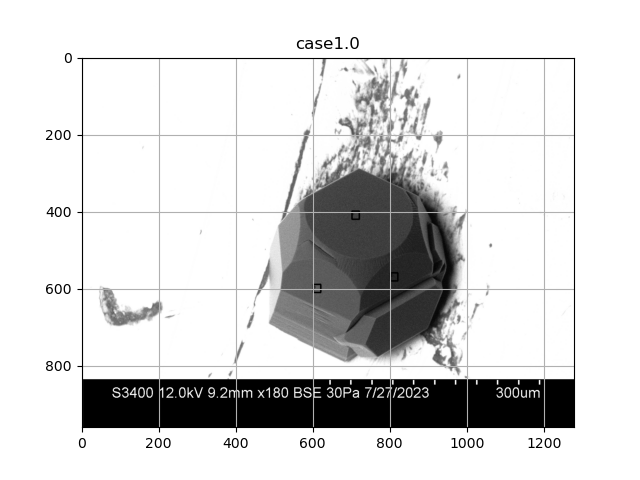

In [5]:
# For development
reload(ims2)

ABCDangle_deg = 16

# Open up a figure and set up the drawing function
imageroot = 'case1.0'
dx,dy,cA,cB,cC,cD,Filename = ims.getc2('', 'SEMimages/', imageroot,'A')
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)
plt.figure()

# Specify the calibration boxes
nx1list,nx2list,ny1list,ny2list = ims2.get_box_lists('Boxes.nml',draw)

# Setup the angle manager with default Euler angles
alpha_default = -173.0
beta_default = 50
gamma_default = 14
xorigin = 712
yorigin = 684
angleManager = ExtlvecxAngleManager(xorigin,yorigin,alpha_default, beta_default, gamma_default)
angleManager.calculate_starts()
angleManager.construct_rotation_matrices()

# Get the nvecs
cvecdir = 'pointingdown' # Alternative is 'pointingup' 
boxa= 'pyramidal' # Alternative is 'prismatic'
boxb= 'pyramidal' # Alternative is 'prismatic'
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)

# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

### Fine-tuning the Euler angles

In [7]:
reload(ims2)
ims2.get_box_lists('Boxes.nml',draw)
desired_facet_angles = [[0,1,62.0],[0,2,62.0],[1,2,52.395]]
print('desired_facet_angles', desired_facet_angles)

angle_number = 3
angle_range = 2
alpha_min = np.max([-180, alpha_default-angle_range]); alpha_max = np.min([180,alpha_default+angle_range]); print(alpha_min,alpha_max)
beta_min = np.max([0, beta_default-angle_range]); beta_max = np.min([180, beta_default+angle_range]); print (beta_min,beta_max)
gamma_min = np.max([-180, gamma_default-angle_range]); gamma_max = np.min([180,gamma_default+angle_range]); print(gamma_min,gamma_max)
least_error = 1e5
for alpha in np.linspace(alpha_min,alpha_max,angle_number):
    for beta in np.linspace(beta_min,beta_max,angle_number):
        for gamma in np.linspace(gamma_min,gamma_max,angle_number):
            angleManager.alpha   = alpha
            angleManager.beta    = beta
            angleManager.gamma   = gamma
            angleManager.update()
            navec, nbvec, ndvec = ims2.get_nvecs(\
                angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)
            pA, pB, pC, pD, response_function_error = ims2.response_function(\
                navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot,ABCDangle_deg = ABCDangle_deg)
            surfaces, sfunctions, retrieval_error = ims2.retrieve_segments(\
                pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, \
                imageroot, dx=dx, dy=dy, overlapping=False, desired_facet_angles=desired_facet_angles)
            if retrieval_error < least_error:
                alpha_best = alpha
                beta_best = beta
                gamma_best = gamma
                pA_best = pA
                pB_best = pB
                pC_best = pC
                pD_best = pD
                least_error = retrieval_error
                print('New alpha, beta, gamma = ', alpha_best,beta_best,gamma_best,retrieval_error)
print('best alpha, beta, gamma, pA, and error = ', alpha_best, beta_best, gamma_best, pA_best, least_error)

# angleManager.alpha   = alpha_best
# angleManager.beta    = beta_best
# angleManager.gamma   = gamma_best
# angleManager.update()
# navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)
# error = ims2.response_function(navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot,graphics=True)
# print(error)

# im = PIL.Image.open(Filename)
# draw = PIL.ImageDraw.Draw(im)
# plt.figure()

# ims2.get_box_lists('Boxes.nml',draw)

# angleManager.alpha   = alpha_best
# angleManager.beta    = beta_best
# angleManager.gamma   = gamma_best
# angleManager.update()
# navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)

# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

nboxes = 3
desired_facet_angles [[0, 1, 62.0], [0, 2, 62.0], [1, 2, 52.395]]
-175.0 -171.0
48 52
12 16
nsegments  3
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 3 )
for 600 590
Observed intensities (detector B):
mean, max, min = 44.3925 60.0 31.0
<diff>, std(diff), di2 = 5.153762294407886 10.74562373641539 4734.465741295316
<diff>, std(diff), di2 = 5.731068563016803 5.746710788443062 17.254490143258025
<diff>, std(diff), di2 = 5.754552717685378 5.6985424989361455 0.026692149038704052

Segment: 1 ( 2 of 3 )
for 800 560
Observed intensities (detector B):
mean, max, min = 51.075 67.0 32.0
<diff>, std(diff), di2 = 10.533137294407886 28.7370868530905 50887.22178358906
<diff>, std(diff), di2 = 7.8708104190092465 9.427722367758449 2766.735418956224
<diff>, std(diff), di2 = 6.779055094845606 7.854492438460916 212.13347598932359
<diff>, std(diff), di2 = 6.381722111020656 7.95081847285467 11.664585262626902
<diff>, std(diff), di2 = 6.288461218442073 8

### Checking how we did

response_function_error  86.9104207850035
nsegments  3
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 3 )
for 600 590
Observed intensities (detector B):
mean, max, min = 44.3925 60.0 31.0
<diff>, std(diff), di2 = 5.175284992989821 10.440289988292841 4308.911848347841
<diff>, std(diff), di2 = 5.615749565262693 5.91339578596634 13.287127803373432
<diff>, std(diff), di2 = 5.630734583510712 5.880458740626127 0.019335392734747332

Segment: 1 ( 2 of 3 )
for 800 560
Observed intensities (detector B):
mean, max, min = 51.075 67.0 32.0
<diff>, std(diff), di2 = 10.554659992989816 28.170833850600346 48694.549747081
<diff>, std(diff), di2 = 8.134366521918857 9.114084435389401 2487.342299380988
<diff>, std(diff), di2 = 7.137868583271267 7.68511836587039 170.4022741191966
<diff>, std(diff), di2 = 6.798989899846372 7.796805187542755 8.079727537291118
Noverlap = 0

Segment: 2 ( 3 of 3 )
for 700 400
Observed intensities (detector B):
mean, max, min = 0.6325 6.

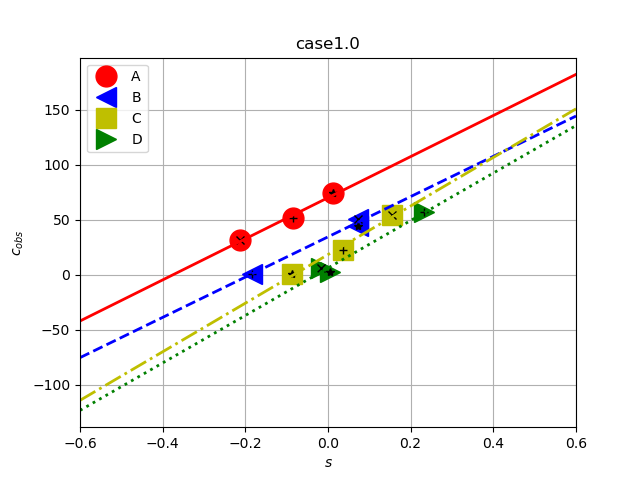

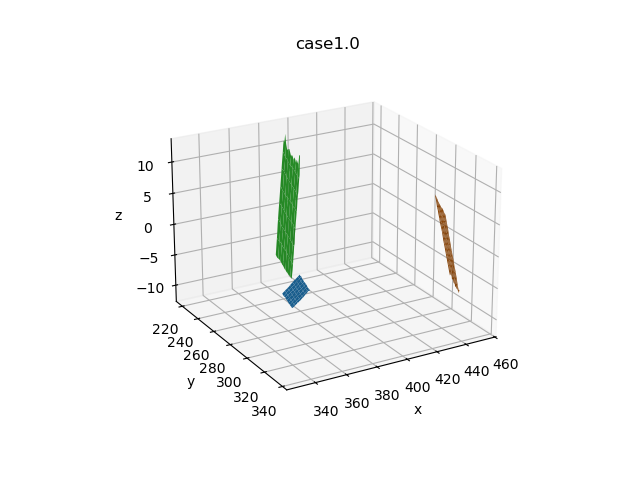

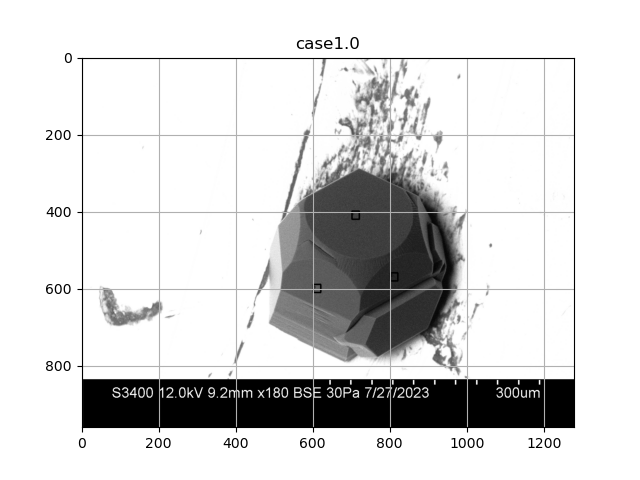

In [9]:
pA, pB, pC, pD, response_function_error = ims2.response_function(\
    navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot, graphics=True)
print('response_function_error ', response_function_error)

surfaces, sfunctions, angle_error = ims2.retrieve_segments(\
    pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, \
    imageroot, dx=dx, dy=dy, overlapping=False, desired_facet_angles=desired_facet_angles, graphics=True)
print('angle_error ', angle_error)

plt.figure()
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)

ims2.get_box_lists('Boxes.nml',draw)

angleManager.alpha   = alpha_best
angleManager.beta    = beta_best
angleManager.gamma   = gamma_best
angleManager.update()
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)


# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

### Saving the calibration

In [11]:
Calibrationfile = 'Calibration.nml'
cfile = open(Calibrationfile,'w')
cfile.write('&Calibration\n')
cfile.write('   '+'pA = '+str(pA[0])+',  '+str(pA[1])+'\n')
cfile.write('   '+'pB = '+str(pB[0])+',  '+str(pB[1])+'\n')
cfile.write('   '+'pC = '+str(pC[0])+',  '+str(pC[1])+'\n')
cfile.write('   '+'pD = '+str(pD[0])+',  '+str(pD[1])+'\n')
cfile.write('/ \n')
cfile.close()

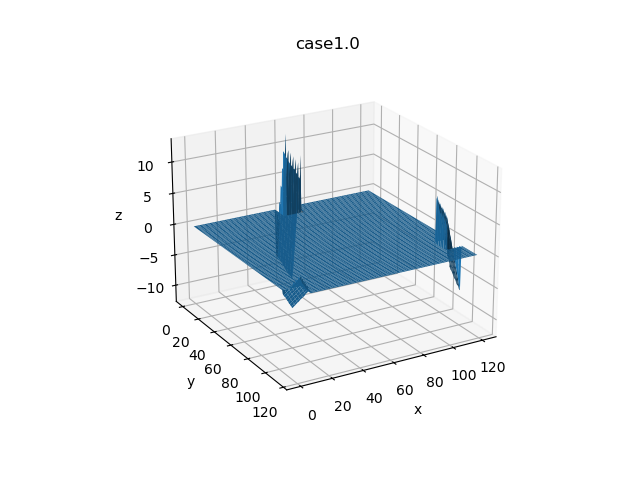

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.invert_yaxis() # invert y axis (this fixes the right-hand-oriented vs left-hand-oriented system)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(imageroot)
ax.view_init(azim=-120,elev=22)
ax.plot_surface(surfaces[0], surfaces[1], surfaces[2], rstride=3 ,cstride=3)

SEMimages/case1.0-A.bmp
SEMimages/case1.0-B.bmp
SEMimages/case1.0-C.bmp
SEMimages/case1.0-D.bmp
nboxes = 3


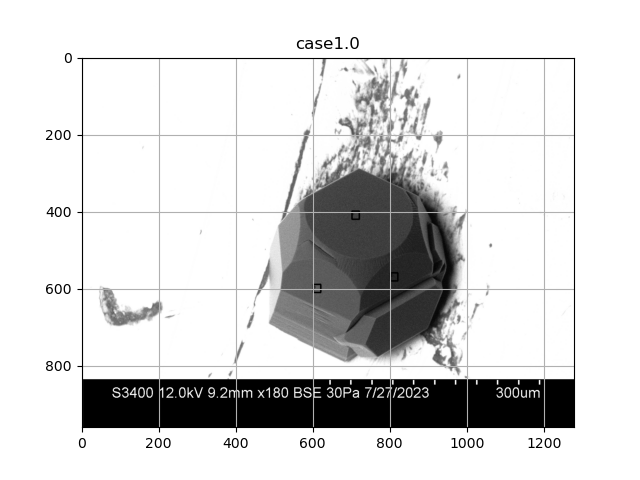

In [13]:
# Open up a figure and set up the drawing function
imageroot = 'case1.0'
dx,dy,cA,cB,cC,cD,Filename = ims.getc2('', 'SEMimages/', imageroot,'A')
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)
plt.figure()

# Specify the calibration boxes
nx1list,nx2list,ny1list,ny2list = ims2.get_box_lists('Boxes.nml',draw)


angleManager = ExtlvecxAngleManager(xorigin,yorigin,alpha_best, beta_best, gamma_best)
angleManager.calculate_starts()
angleManager.construct_rotation_matrices()

# Get the nvecs
cvecdir = 'pointingdown' # Alternative is 'pointingup' 
boxa= 'pyramidal' # Alternative is 'prismatic'
boxb= 'pyramidal' # Alternative is 'prismatic'
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)


# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)